# 📊 Комплексный EDA — Travel Analytics
Разведочный анализ бронирований билетов: pandas, numpy, matplotlib.
Техники: merge, groupby, pivot_table, фильтрация, quantile, визуализация.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/Users/bagdauletsundetkaliyev/travel-analytics/powerbi_data"

bookings  = pd.read_csv(f"{BASE}/fact_bookings.csv")
routes    = pd.read_csv(f"{BASE}/dim_route.csv")
customers = pd.read_csv(f"{BASE}/dim_customer.csv")

print("Бронирований:", len(bookings))
bookings.head()

Бронирований: 67560


,booking_id,order_id,customer_key,route_key,date_key,seat_class,order_status,price,ticket_count
0,1,1,6663,17,2026-06-14,business,created,57780.01,1
1,2,2,8273,38,2025-03-27,economy,paid,23599.05,1
2,3,3,1562,25,2025-04-17,business,created,75301.44,1
3,4,4,175,8,2026-07-11,business,cancelled,51034.66,1
4,5,5,9603,1,2026-03-31,economy,paid,30220.83,1


In [12]:
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67560 entries, 0 to 67559
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   booking_id    67560 non-null  int64  
 1   order_id      67560 non-null  int64  
 2   customer_key  67560 non-null  int64  
 3   route_key     67560 non-null  int64  
 4   date_key      67560 non-null  object 
 5   seat_class    67560 non-null  object 
 6   order_status  67560 non-null  object 
 7   price         67560 non-null  float64
 8   ticket_count  67560 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 4.6+ MB


In [13]:
bookings.describe()

,booking_id,order_id,customer_key,route_key,price,ticket_count
count,67560.00000,67560.000000,67560.000000,67560.000000,67560.000000,67560.0
mean,33780.50000,25002.115364,4995.335790,30.539343,27769.487930,1.0
std,19503.03643,14420.549081,2882.047576,17.294245,24921.950882,0.0
min,1.00000,1.000000,1.000000,1.000000,1600.060000,1.0
25%,16890.75000,12501.000000,2509.750000,16.000000,10301.787500,1.0
50%,33780.50000,25032.000000,4964.000000,31.000000,20987.855000,1.0
75%,50670.25000,37457.250000,7494.250000,45.000000,38089.497500,1.0
max,67560.00000,50000.000000,10000.000000,60.000000,152281.810000,1.0


In [16]:
print("Пропуски: \n", bookings.isna().sum(), "\n")

before = len(bookings);
bookings = bookings.drop_duplicates()
print("Удаленно дупликатов: ", before - len(bookings))

bookings["seat_class"] = bookings["seat_class"].fillna("economy")
bookings = bookings.dropna(subset = ["price"])
print("Строк после чистки:", len(bookings))


Пропуски: 
 booking_id      0
order_id        0
customer_key    0
route_key       0
date_key        0
seat_class      0
order_status    0
price           0
ticket_count    0
dtype: int64 

Удаленно дупликатов:  0
Строк после чистки: 67560


In [17]:
bookings["date_key"] = pd.to_datetime(bookings["date_key"])
bookings["month"] = bookings["date_key"].dt.month
bookings["year"] = bookings["date_key"].dt.year
bookings.dtypes

booking_id               int64
order_id                 int64
customer_key             int64
route_key                int64
date_key        datetime64[ns]
seat_class              object
order_status            object
price                  float64
ticket_count             int64
month                    int64
year                     int64
dtype: object

In [20]:
df = bookings.merge(routes, left_on = "route_key",right_on = "route_id",how = "left")
df = df.merge(customers,left_on="customer_key", right_on = "customer_id", how = "left")
df[["booking_id", "price", "origin_city", "destination_city", "transport_type", "city"]].head()

,booking_id,price,origin_city,destination_city,transport_type,city
0,1,57780.01,Атырау,Усть-Каменогорск,avia,Шымкент
1,2,23599.05,Стамбул,Костанай,avia,Дубай
2,3,75301.44,Астана,Дубай,avia,Санкт-Петербург
3,4,51034.66,Алматы,Актобе,avia,Актобе
4,5,30220.83,Актобе,Бишкек,avia,Ташкент


In [21]:
# Оплаченные дорогие билеты бизнес-класса
mask = (df["order_status"] == "paid") & (df["price"] > 50000) & (df["seat_class"] == "business")
expensive = df[mask]
print("Дорогих business-билетов:", len(expensive))

# ИЛИ: билеты из Астаны или Алматы
kz = df[(df["origin_city"] == "Астана") | (df["origin_city"] == "Алматы")]
print("Из Астаны/Алматы:", len(kz))

Дорогих business-билетов: 4177
Из Астаны/Алматы: 11426


In [24]:
summary = df.groupby("transport_type").agg(
    revenue=("price", "sum"),
    tickets=("booking_id", "count"),
    avg_price=("price", "mean"),
).sort_values("revenue", ascending=False)
summary

,revenue,tickets,avg_price
transport_type,,,
avia,1.614524e+09,43959,36727.949528
rail,2.615827e+08,23601,11083.541850


In [23]:
df["origin_city"].value_counts().head(10)

Астана              9079
Санкт-Петербург     7785
Усть-Каменогорск    6632
Стамбул             5780
Павлодар            4540
Кызылорда           4494
Атырау              4486
Москва              3390
Тараз               3336
Дубай               3333
Name: origin_city, dtype: int64

In [25]:
print("25% : ",round(df["price"].quantile(0.25)))
print("50% :", round(df["price"].quantile(0.5)))
print("95% :", round(df["price"].quantile(0.95)))

25% :  10302
50% : 20988
95% : 83930


In [26]:
pivot = df.pivot_table(values = "price",index="transport_type",columns="seat_class",aggfunc="mean")
pivot.round(0)

seat_class,business,economy
transport_type,,
avia,70257.0,28276.0
rail,21396.0,8541.0


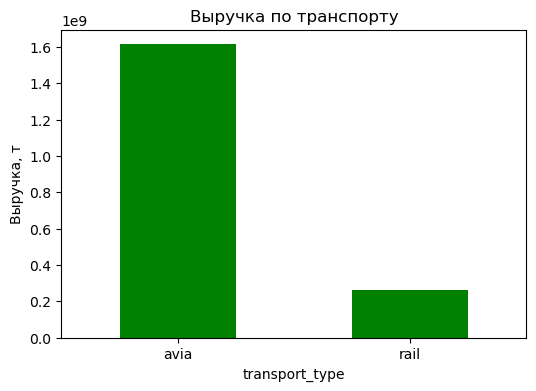

In [27]:
summary["revenue"].plot(kind = "bar",color = "green",figsize=(6,4),title="Выручка по транспорту")
plt.ylabel("Выручка, т"); plt.xticks(rotation = 0); 
plt.show()

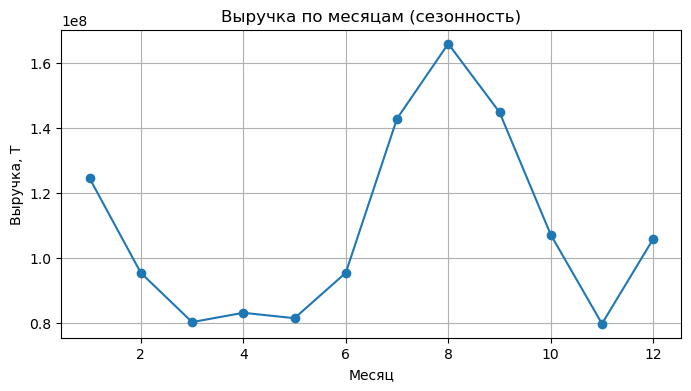

In [30]:
monthly = df[df["order_status"] == "paid"].groupby("month")["price"].sum()
monthly.plot(kind = "line",marker = "o",figsize = (8,4), title = "Выручка по месяцам (сезонность)")
plt.xlabel("Месяц"); plt.ylabel("Выручка, Т"); plt.grid(True);
plt.show()

In [31]:
summary.to_excel(f"{BASE}/transport_summary.xlsx")
excel_df = pd.read_excel(f"{BASE}/transport_summary.xlsx")
print("Прочитано из Excel:")
excel_df

Прочитано из Excel:


,transport_type,revenue,tickets,avg_price
0,avia,1.614524e+09,43959,36727.949528
1,rail,2.615827e+08,23601,11083.541850


## Выводы
- Цены имеют длинный правый хвост (медиана << 95-й перцентиль).
- Avia даёт ~86% выручки, business дороже economy в ~2.5 раза.
- Выражена сезонность: пик летом и в декабре.
- Данные чистые (пропусков и дублей нет — результат dbt-тестов).